# Scout de finalizações

## Pergunta

Quais jogadores da amostra produziram mais perigo com suas finalizações?

## Fonte dos dados

StatsBomb Open Data.

## Métricas

- Finalizações
- Gols
- xG acumulado
- xG por finalização
- Gols menos xG

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

from statsbombpy import sb

In [75]:
competitions = sb.competitions()

competitions.head()

/Users/th3g3ntl3man/Documents/github/european-player-scout/.venv/lib/python3.14/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,NaN,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882


In [76]:
competitions[
    [
        "competition_id",
        "season_id",
        "country_name",
        "competition_name",
        "season_name",
        "competition_gender",
    ]
].drop_duplicates()

,competition_id,season_id,country_name,competition_name,season_name,competition_gender
0,9,281,Germany,1. Bundesliga,2023/2024,male
1,9,27,Germany,1. Bundesliga,2015/2016,male
2,1267,107,Africa,African Cup of Nations,2023,male
3,16,4,Europe,Champions League,2018/2019,male
4,16,1,Europe,Champions League,2017/2018,male
...,...,...,...,...,...,...
75,35,75,Europe,UEFA Europa League,1988/1989,male
76,53,315,Europe,UEFA Women's Euro,2025,female
77,53,106,Europe,UEFA Women's Euro,2022,female
78,72,107,International,Women's World Cup,2023,female


In [77]:
COMPETITION_ID = 9
SEASON_ID = 281

In [78]:
matches = sb.matches(
    competition_id = COMPETITION_ID,
    season_id = SEASON_ID,
)

matches[
    [
        "match_id",
        "match_date",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
    ]
].head()

/Users/th3g3ntl3man/Documents/github/european-player-scout/.venv/lib/python3.14/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,match_date,home_team,away_team,home_score,away_score
0,3895292,2024-04-06,Union Berlin,Bayer Leverkusen,0,1
1,3895320,2024-04-27,Bayer Leverkusen,VfB Stuttgart,2,2
2,3895158,2023-12-03,Bayer Leverkusen,Borussia Dortmund,1,1
3,3895107,2023-10-08,Bayer Leverkusen,FC Köln,3,0
4,3895340,2024-05-12,Bochum,Bayer Leverkusen,0,5


In [79]:
sample_matches = matches

sample_matches[
    ["match_id", "home_team", "away_team"]
]

,match_id,home_team,away_team
0,3895292,Union Berlin,Bayer Leverkusen
1,3895320,Bayer Leverkusen,VfB Stuttgart
2,3895158,Bayer Leverkusen,Borussia Dortmund
3,3895107,Bayer Leverkusen,FC Köln
4,3895340,Bochum,Bayer Leverkusen
5,3895286,Bayer Leverkusen,Hoffenheim
6,3895302,Bayer Leverkusen,Werder Bremen
7,3895333,Eintracht Frankfurt,Bayer Leverkusen
8,3895348,Bayer Leverkusen,Augsburg
9,3895220,Darmstadt 98,Bayer Leverkusen


In [80]:
events = pd.concat(
    [
        sb.events(match_id=match_id)
        for match_id in sample_matches["match_id"]
    ],
    ignore_index=True
)

events.shape

/Users/th3g3ntl3man/Documents/github/european-player-scout/.venv/lib/python3.14/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


(137765, 111)

In [81]:
events.columns.tolist()

['50_50',
 'ball_receipt_outcome',
 'ball_recovery_offensive',
 'ball_recovery_recovery_failure',
 'block_deflection',
 'block_offensive',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_penalty',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'injury_stoppage_in_chain',
 'interception_outcome',
 'location',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_locati

In [82]:
events["type"].value_counts().head(15)

type
Pass              39214
Ball Receipt*     38215
Carry             32369
Pressure          11419
Ball Recovery      3222
Duel               2022
Block              1434
Clearance          1248
Goal Keeper        1102
Shot                916
Dribble             913
Miscontrol          903
Dispossessed        759
Foul Committed      758
Interception        738
Name: count, dtype: int64

In [83]:
shots = events.loc[
    events["type"].eq("Shot"),
    [
        "match_id",
        "player",
        "team",
        "minute",
        "shot_outcome",
        "shot_statsbomb_xg",
        "shot_type",
    ]
].copy()

In [84]:
shots["is_goal"] = (
    shots["shot_outcome"]
    .eq("Goal")
    .astype(int)
)

In [85]:
ranking = (
    shots
    .dropna(subset=["player"])
    .groupby(["player", "team"], as_index=False)
    .agg(
        shots=("player", "size"),
        goals=("is_goal", "sum"),
        total_xg=("shot_statsbomb_xg", "sum"),
        xg_per_shot=("shot_statsbomb_xg", "mean"),
    )
)

In [86]:
ranking["goals_minus_xg"] = (
    ranking["goals"] - ranking["total_xg"]
)

In [87]:
ranking = ranking.sort_values(
    "total_xg",
    ascending=False,
)

top_players_by_team = (
    ranking
    .sort_values("total_xg", ascending=False)
    .groupby("team")
    .head(3)
)

top_players_by_team

,player,team,shots,goals,total_xg,xg_per_shot,goals_minus_xg
170,Victor Okoh Boniface,Bayer Leverkusen,81,14,15.970215,0.197163,-1.970215
71,Jeremie Frimpong,Bayer Leverkusen,56,9,8.719662,0.155708,0.280338
52,Florian Wirtz,Bayer Leverkusen,71,11,8.470831,0.119307,2.529169
159,Serhou Guirassy,VfB Stuttgart,9,0,1.871088,0.207899,-1.871088
65,Ikoma Loïs Openda,RB Leipzig,6,2,1.358279,0.226380,0.641721
173,Wout Weghorst,Hoffenheim,3,1,1.099952,0.366651,-0.099952
25,Chris Führich,VfB Stuttgart,6,2,1.096848,0.182808,0.903152
137,Oscar Vilhelmsson,Darmstadt 98,4,1,0.904144,0.226036,0.095856
61,Harry Kane,Bayern Munich,3,1,0.889875,0.296625,0.110125
44,Eric Martel,FC Köln,2,0,0.735629,0.367815,-0.735629


In [88]:
ranking_display = ranking.copy()

columns_to_round = [
    "total_xg",
    "xg_per_shot",
    "goals_minus_xg",
]

ranking_display[columns_to_round] = (
    ranking_display[columns_to_round].round(2)
)

ranking_display.head(10)

,player,team,shots,goals,total_xg,xg_per_shot,goals_minus_xg
170,Victor Okoh Boniface,Bayer Leverkusen,81,14,15.97,0.20,-1.97
71,Jeremie Frimpong,Bayer Leverkusen,56,9,8.72,0.16,0.28
52,Florian Wirtz,Bayer Leverkusen,71,11,8.47,0.12,2.53
73,Jonas Hofmann,Bayer Leverkusen,62,4,5.71,0.09,-1.71
139,Patrik Schick,Bayer Leverkusen,40,7,5.45,0.14,1.55
2,Alejandro Grimaldo García,Bayer Leverkusen,71,10,5.21,0.07,4.79
125,Nathan Tella,Bayer Leverkusen,21,5,3.76,0.18,1.24
4,Amine Adli,Bayer Leverkusen,27,4,3.09,0.11,0.91
0,Adam Hložek,Bayer Leverkusen,19,2,3.01,0.16,-1.01
46,Exequiel Alejandro Palacios,Bayer Leverkusen,21,4,2.69,0.13,1.31


In [89]:
shots.isna().sum()

match_id             0
player               0
team                 0
minute               0
shot_outcome         0
shot_statsbomb_xg    0
shot_type            0
is_goal              0
dtype: int64

In [90]:
player_name = ranking.iloc[0]["player"]

player_shots = shots[
    shots["player"].eq(player_name)
]

player_shots[
    [
        "player",
        "team",
        "minute",
        "shot_outcome",
        "shot_statsbomb_xg",
        "shot_type",
    ]
]

,player,team,minute,shot_outcome,shot_statsbomb_xg,shot_type
11255,Victor Okoh Boniface,Bayer Leverkusen,37,Off T,0.063404,Open Play
11273,Victor Okoh Boniface,Bayer Leverkusen,78,Goal,0.940326,Open Play
11274,Victor Okoh Boniface,Bayer Leverkusen,86,Saved,0.081225,Open Play
15514,Victor Okoh Boniface,Bayer Leverkusen,11,Blocked,0.061079,Open Play
15515,Victor Okoh Boniface,Bayer Leverkusen,11,Saved,0.134035,Open Play
...,...,...,...,...,...,...
133913,Victor Okoh Boniface,Bayer Leverkusen,55,Off T,0.067178,Open Play
133925,Victor Okoh Boniface,Bayer Leverkusen,86,Saved,0.029618,Open Play
137545,Victor Okoh Boniface,Bayer Leverkusen,36,Saved,0.132262,Open Play
137549,Victor Okoh Boniface,Bayer Leverkusen,56,Off T,0.042780,Open Play


In [91]:
player_shots["shot_statsbomb_xg"].sum()

np.float64(15.9702154796)

In [92]:
player_shots["is_goal"].sum()

np.int64(14)

In [93]:
shots["shot_type"].value_counts(dropna=False)

shot_type
Open Play    882
Free Kick     26
Penalty        8
Name: count, dtype: int64

In [94]:
non_penalty_shots = shots[
    shots["shot_type"].ne("Penalty")
].copy()

In [95]:
non_penalty_shots.head()

,match_id,player,team,minute,shot_outcome,shot_statsbomb_xg,shot_type,is_goal
3669,3895292,Borja Iglesias Quintas,Bayer Leverkusen,2,Off T,0.084877,Open Play,0
3670,3895292,Granit Xhaka,Bayer Leverkusen,5,Blocked,0.042399,Open Play,0
3671,3895292,Adam Hložek,Bayer Leverkusen,6,Blocked,0.017574,Open Play,0
3672,3895292,Alejandro Grimaldo García,Bayer Leverkusen,10,Saved,0.075614,Free Kick,0
3673,3895292,Borja Iglesias Quintas,Bayer Leverkusen,14,Saved,0.118389,Open Play,0


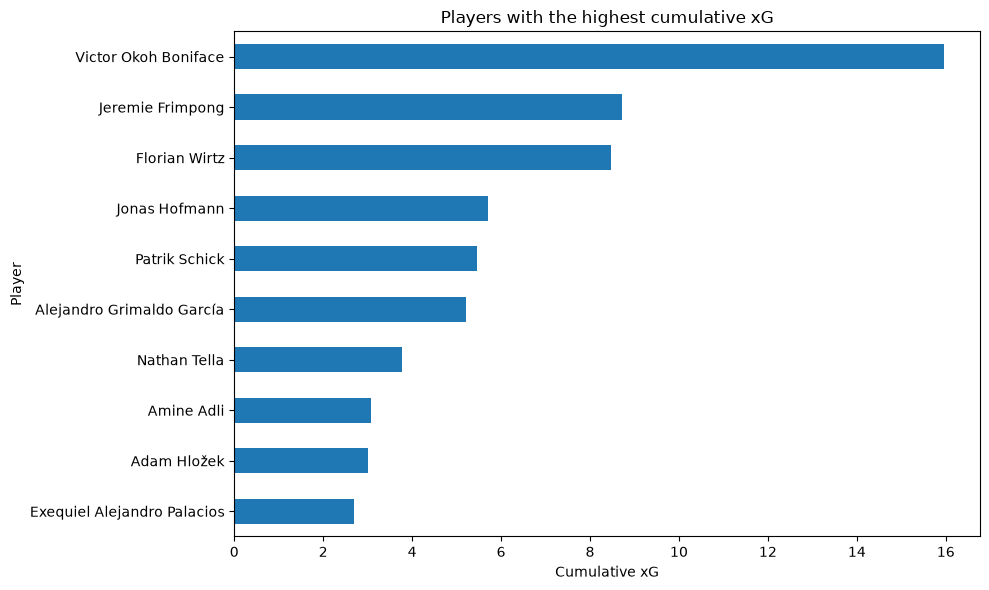

In [98]:
top_players = (
    ranking
    .head(10)
    .sort_values("total_xg")
)

ax = top_players.plot.barh(
    x="player",
    y="total_xg",
    legend=False,
    figsize=(10, 6),
)

ax.set_title("Players with the highest cumulative xG")
ax.set_xlabel("Cumulative xG")
ax.set_ylabel("Player")

plt.tight_layout()

plt.savefig(
    "../reports/figures/top_players_total_xg.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [100]:
from adjustText import adjust_text

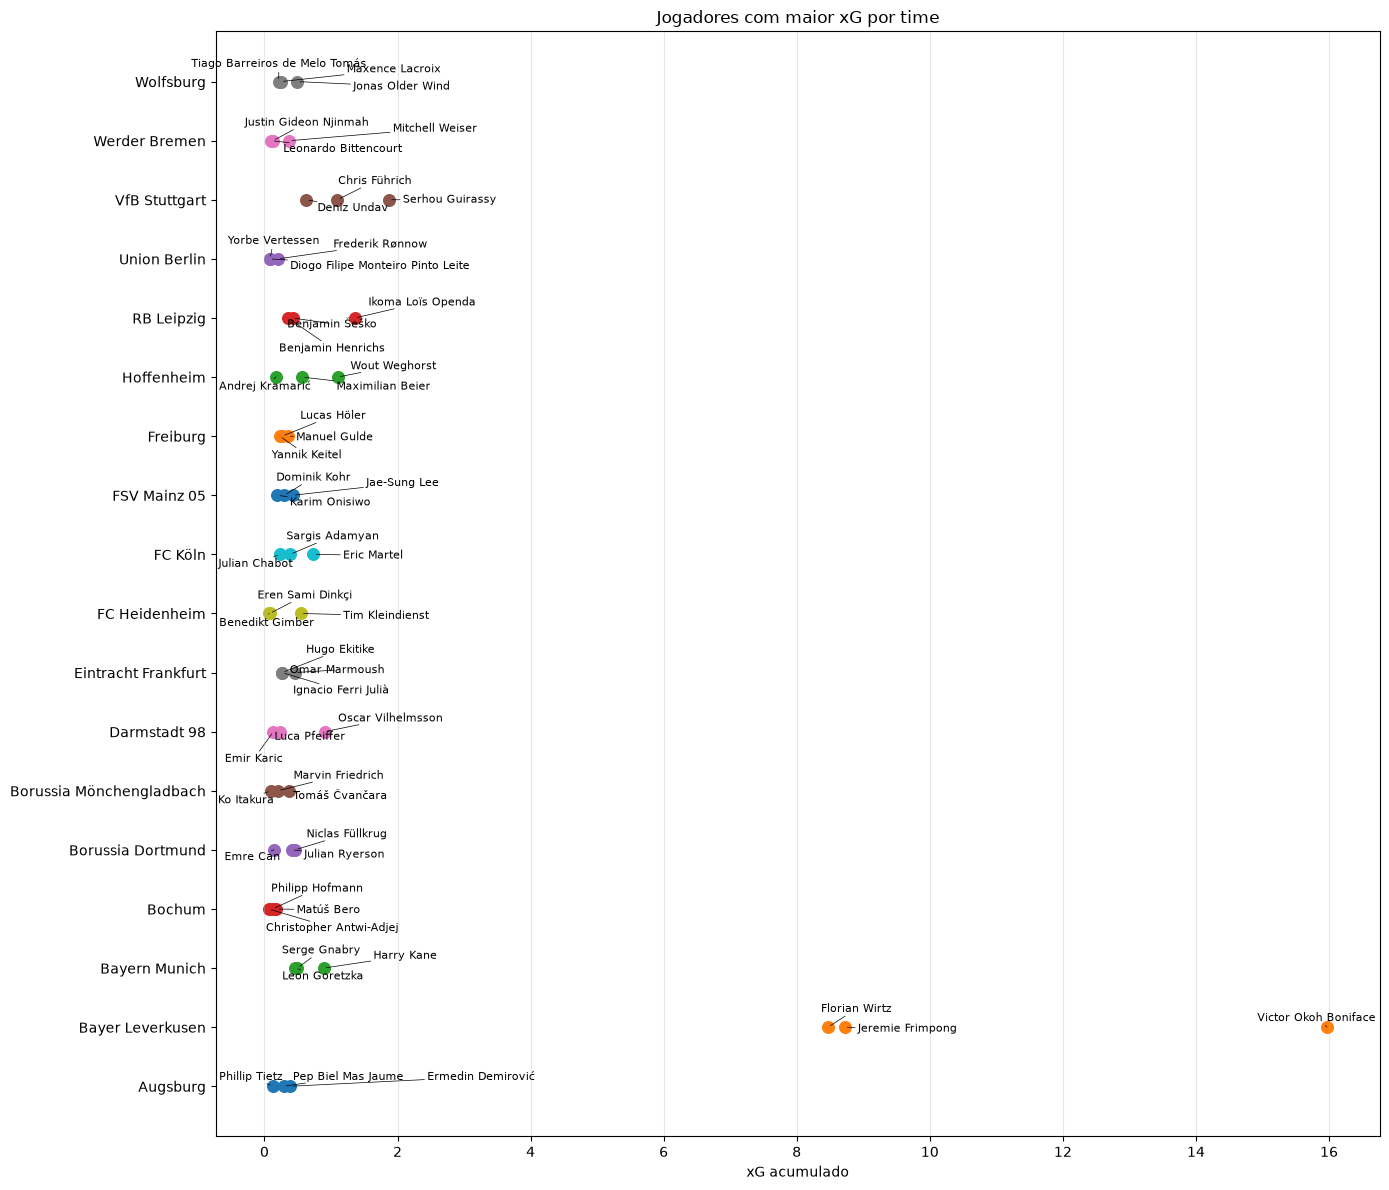

In [103]:
fig, ax = plt.subplots(figsize=(14, 12))

texts = []

for team, group in top_players_by_team.groupby("team"):
    ax.scatter(
        group["total_xg"],
        [team] * len(group),
        s=70,
    )

    for _, row in group.iterrows():
        texts.append(
            ax.text(
                row["total_xg"],
                row["team"],
                row["player"],
                fontsize=8,
            )
        )

adjust_text(
    texts,
    ax=ax,
    arrowprops={
        "arrowstyle": "-",
        "linewidth": 0.5,
    },
)

ax.set_title("Jogadores com maior xG por time")
ax.set_xlabel("xG acumulado")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.3)

plt.savefig(
    "../reports/figures/top_players_total_xg_scatter.png",
    dpi=150,
    bbox_inches="tight",
)

plt.tight_layout()
plt.show()